# Análise de Satisfação de Clientes — Olist

## Contexto de Negócio
O time comercial da Olist identificou queda na satisfação dos clientes e 
solicitou uma análise para entender os principais fatores que impactam 
a experiência de compra.

## Objetivo
Identificar os principais drivers de insatisfação dos clientes com base 
em dados reais de pedidos, entregas e avaliações.

## Ferramentas Utilizadas
- Python (Pandas, Matplotlib, Seaborn)
- Jupyter Notebook

## Dataset
[Brazilian E-Commerce — Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

In [18]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [19]:
# Carregando os dados
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

print("Dados carregados com sucesso!")
print(f"Pedidos: {orders.shape}")
print(f"Clientes: {customers.shape}")
print(f"Itens: {order_items.shape}")
print(f"Avaliações: {order_reviews.shape}")
print(f"Produtos: {products.shape}")

Dados carregados com sucesso!
Pedidos: (99441, 8)
Clientes: (99441, 5)
Itens: (112650, 7)
Avaliações: (99224, 7)
Produtos: (32951, 9)


In [20]:
# Primeira olhada nos pedidos
print("=== PEDIDOS ===")
print(f"Total de pedidos: {orders.shape[0]}")
print(f"\nStatus dos pedidos:")
print(orders['order_status'].value_counts())

=== PEDIDOS ===
Total de pedidos: 99441

Status dos pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [21]:
# Analisando as avaliações dos clientes
print("=== AVALIAÇÕES ===")
print(f"Total de avaliações: {order_reviews.shape[0]}")
print(f"\nDistribuição das notas:")
print(order_reviews['review_score'].value_counts().sort_index())
print(f"\nNota média geral: {order_reviews['review_score'].mean():.2f}")

=== AVALIAÇÕES ===
Total de avaliações: 99224

Distribuição das notas:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Nota média geral: 4.09


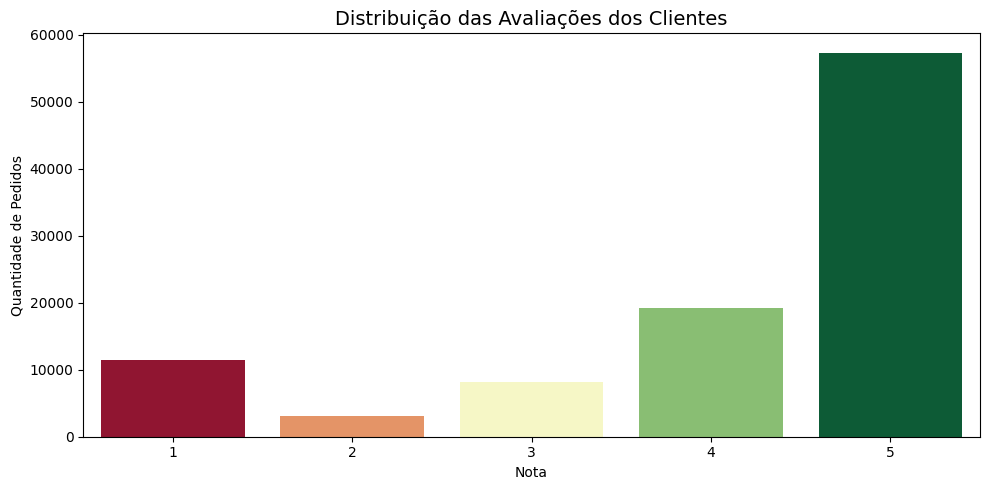

In [22]:
# Visualizando a distribuição das notas
plt.figure(figsize=(10, 5))
sns.countplot(data=order_reviews, x='review_score', hue='review_score', palette='RdYlGn', legend=False)
plt.title('Distribuição das Avaliações dos Clientes', fontsize=14)
plt.xlabel('Nota')
plt.ylabel('Quantidade de Pedidos')
plt.tight_layout()
plt.show()

In [23]:
# Analisando o prazo de entrega
# Convertendo datas
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Calculando atraso (dias reais vs dias prometidos)
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['dias_atraso'] = (
    orders_delivered['order_delivered_customer_date'] - 
    orders_delivered['order_estimated_delivery_date']
).dt.days

print(f"Pedidos entregues no prazo ou antes: {(orders_delivered['dias_atraso'] <= 0).sum()}")
print(f"Pedidos entregues com atraso: {(orders_delivered['dias_atraso'] > 0).sum()}")
print(f"\nAtraso médio (em dias): {orders_delivered['dias_atraso'].mean():.1f}")
print(f"Maior atraso registrado: {orders_delivered['dias_atraso'].max()} dias")

Pedidos entregues no prazo ou antes: 89936
Pedidos entregues com atraso: 6534

Atraso médio (em dias): -11.9
Maior atraso registrado: 188.0 dias


In [24]:
# Cruzando atraso com avaliação
# Unindo pedidos com avaliações
orders_reviews = orders_delivered.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')

# Nota média por situação de atraso
orders_reviews['atrasado'] = orders_reviews['dias_atraso'] > 0

print("Nota média por situação de entrega:")
print(orders_reviews.groupby('atrasado')['review_score'].mean().round(2))
print("\nFalse = entregue no prazo | True = entregue com atraso")

Nota média por situação de entrega:
atrasado
False    4.29
True     2.27
Name: review_score, dtype: float64

False = entregue no prazo | True = entregue com atraso


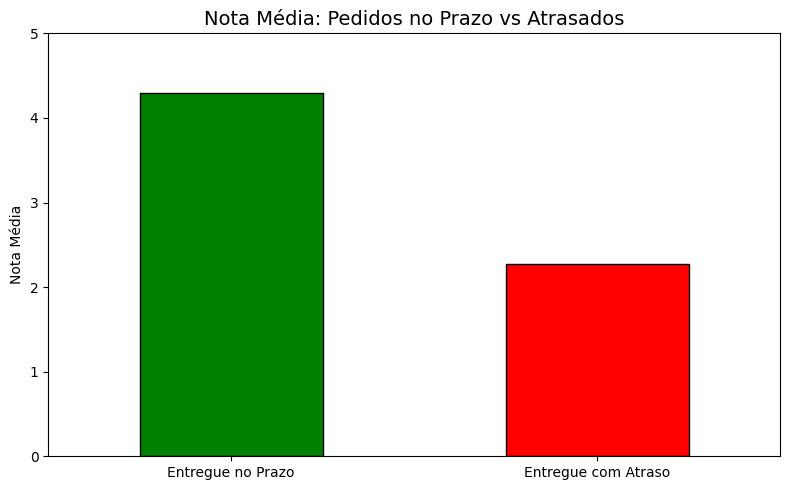

In [25]:
# Visualizando nota média por situação de entrega
plt.figure(figsize=(8, 5))
orders_reviews.groupby('atrasado')['review_score'].mean().plot(
    kind='bar',
    color=['green', 'red'],
    edgecolor='black'
)
plt.title('Nota Média: Pedidos no Prazo vs Atrasados', fontsize=14)
plt.xlabel('')
plt.xticks([0, 1], ['Entregue no Prazo', 'Entregue com Atraso'], rotation=0)
plt.ylabel('Nota Média')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

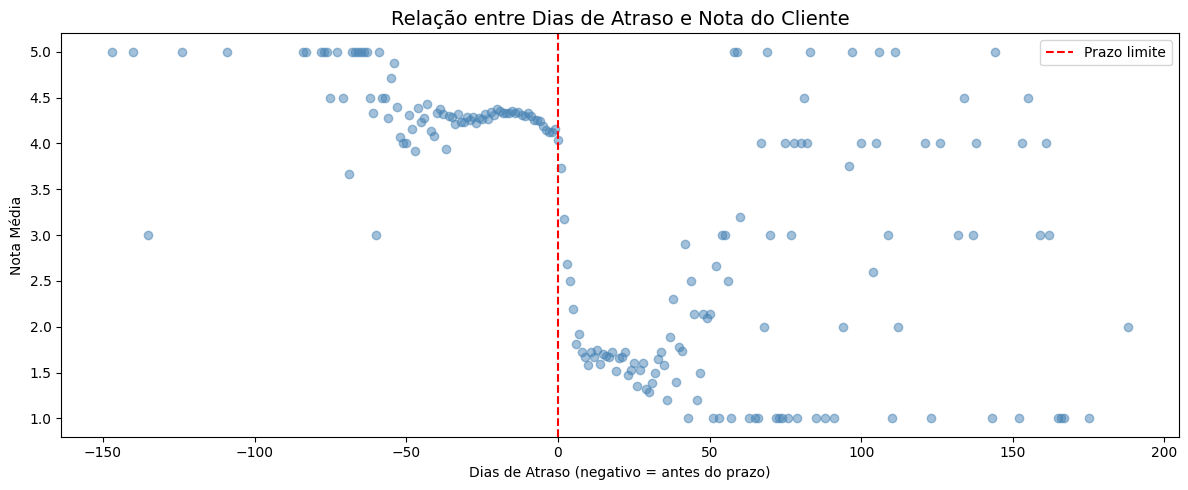

In [26]:
# Nota média por dias de atraso
atraso_nota = orders_reviews.groupby('dias_atraso')['review_score'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.scatter(atraso_nota['dias_atraso'], atraso_nota['review_score'], alpha=0.5, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', label='Prazo limite')
plt.title('Relação entre Dias de Atraso e Nota do Cliente', fontsize=14)
plt.xlabel('Dias de Atraso (negativo = antes do prazo)')
plt.ylabel('Nota Média')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Carregando tabela de categorias
category_translation = pd.read_csv('product_category_name_translation.csv')

# Unindo todas as tabelas necessárias
df = orders_reviews.merge(order_items[['order_id', 'product_id']], on='order_id', how='left')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')

# Top 10 categorias com pior nota média
pior_nota = df.groupby('product_category_name_english')['review_score'].mean().sort_values().head(10).round(2)

print("Top 10 categorias com pior avaliação:")
print(pior_nota)

Top 10 categorias com pior avaliação:
product_category_name_english
security_and_services                2.50
diapers_and_hygiene                  3.38
office_furniture                     3.52
home_comfort_2                       3.63
fashion_male_clothing                3.76
fixed_telephony                      3.76
audio                                3.83
party_supplies                       3.83
home_confort                         3.85
furniture_mattress_and_upholstery    3.89
Name: review_score, dtype: float64


In [28]:
# Investigando security_and_services
security = df[df['product_category_name_english'] == 'security_and_services']

print(f"Total de pedidos: {security.shape[0]}")
print(f"\nDistribuição das notas:")
print(security['review_score'].value_counts().sort_index())

Total de pedidos: 2

Distribuição das notas:
review_score
1.0    1
4.0    1
Name: count, dtype: int64


In [29]:
# Top 10 categorias com pior nota - apenas categorias relevantes (mínimo 100 pedidos)
categoria_volume = df.groupby('product_category_name_english')['review_score'].agg(['mean', 'count']).reset_index()
categoria_relevante = categoria_volume[categoria_volume['count'] >= 100]
pior_nota_relevante = categoria_relevante.sort_values('mean').head(10)

print("Top 10 categorias com pior avaliação (mín. 100 pedidos):")
print(pior_nota_relevante[['product_category_name_english', 'mean', 'count']].round(2))

Top 10 categorias com pior avaliação (mín. 100 pedidos):
   product_category_name_english  mean  count
57              office_furniture  3.52   1664
30         fashion_male_clothing  3.76    124
34               fixed_telephony  3.76    253
4                          audio  3.83    359
47                  home_confort  3.85    430
7                 bed_bath_table  3.92  10985
40         furniture_living_room  3.94    494
39               furniture_decor  3.95   8159
48             home_construction  3.96    593
19     construction_tools_safety  3.97    182


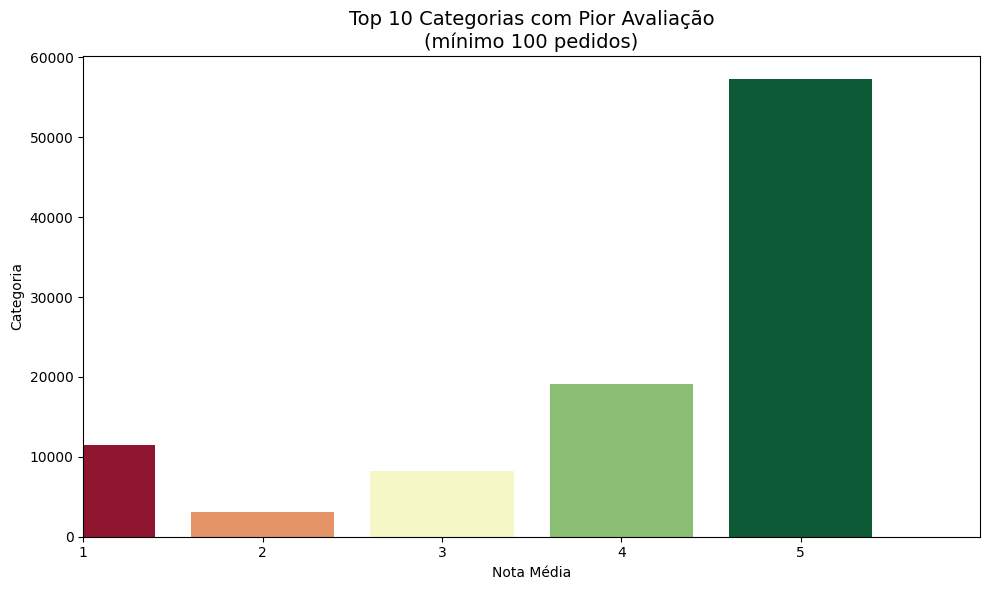

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(data=order_reviews, x='review_score', hue='review_score', palette='RdYlGn', legend=False)
plt.title('Top 10 Categorias com Pior Avaliação\n(mínimo 100 pedidos)', fontsize=14)
plt.xlabel('Nota Média')
plt.ylabel('Categoria')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

In [31]:
# Unindo com a tabela de clientes para pegar o estado
df_geo = orders_reviews.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# Calculando nota média e % de atraso por estado
estado_analise = df_geo.groupby('customer_state').agg(
    nota_media=('review_score', 'mean'),
    total_pedidos=('order_id', 'count'),
    pedidos_atrasados=('atrasado', 'sum')
).reset_index()

estado_analise['pct_atraso'] = (estado_analise['pedidos_atrasados'] / estado_analise['total_pedidos'] * 100).round(1)
estado_analise['nota_media'] = estado_analise['nota_media'].round(2)

print("Análise por estado:")
print(estado_analise.sort_values('nota_media').head(10))

Análise por estado:
   customer_state  nota_media  total_pedidos  pedidos_atrasados  pct_atraso
1              AL        3.84            401                 86        21.4
9              MA        3.84            721                125        17.3
21             RR        3.90             41                  5        12.2
13             PA        3.91            952                106        11.1
24             SE        3.91            335                 51        15.2
4              BA        3.93           3273                400        12.2
5              CE        3.94           1282                177        13.8
18             RJ        3.96          12420               1503        12.1
16             PI        4.00            477                 66        13.8
7              ES        4.08           2004                214        10.7


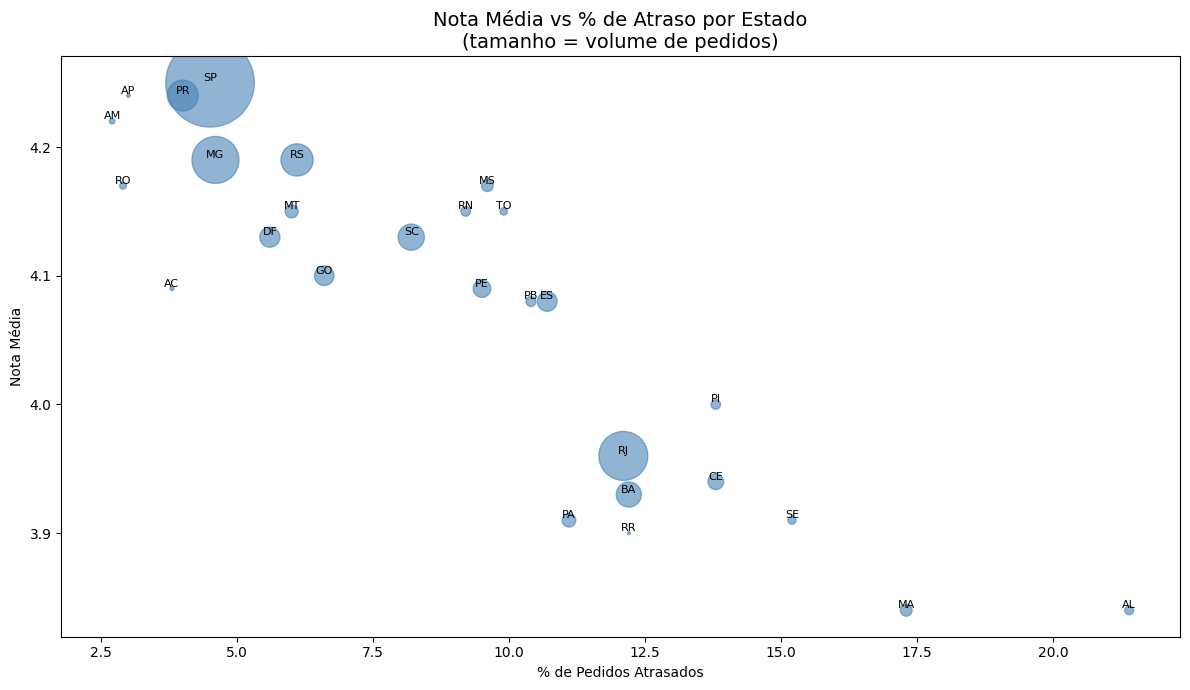

In [32]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    estado_analise['pct_atraso'],
    estado_analise['nota_media'],
    s=estado_analise['total_pedidos']/10,
    alpha=0.6,
    color='steelblue'
)

# Adicionando o nome de cada estado no gráfico
for _, row in estado_analise.iterrows():
    plt.annotate(row['customer_state'], 
                (row['pct_atraso'], row['nota_media']),
                fontsize=8, ha='center', va='bottom')

plt.title('Nota Média vs % de Atraso por Estado\n(tamanho = volume de pedidos)', fontsize=14)
plt.xlabel('% de Pedidos Atrasados')
plt.ylabel('Nota Média')
plt.tight_layout()
plt.show()

## Principais Insights da Análise:

1. **Atraso é o principal vilão da satisfação**: pedidos atrasados têm nota média 2.27 vs 4.29 nos pontos no prazo
2. **O impacto é imediato**: qualquer atraso, mesmo de 1 dia, já derruba a nota drasticamente
3. **Categorias críticas**: office_furniture e bed_bath_table concentram os piores índices com volume relevante
4. **Problema logístico regional**: AL, MA e PA têm os maiores percentuais de atraso e as piores notas
5. **RJ é prioridade**: maior volume de pedidos fora de SP com taxa de atraso de 12%

### Recomendações:
Priorizar a melhora logística no Norte e Nordeste, com foco especial em RJ pelo impacto absoluto no negócio.